In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, precision_score, recall_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [2]:
fold_1_train = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_1_train.csv')
fold_2_train = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_2_train.csv')
fold_3_train = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_3_train.csv')
fold_4_train = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_4_train.csv')
fold_5_train = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_5_train.csv')

fold_1_val = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_1_val.csv')
fold_2_val = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_2_val.csv')
fold_3_val = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_3_val.csv')
fold_4_val = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_4_val.csv')
fold_5_val = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_5_val.csv')

In [3]:
train_folds = [fold_1_train, fold_2_train, fold_3_train, fold_4_train, fold_5_train]
val_folds = [fold_1_val, fold_2_val, fold_3_val, fold_4_val, fold_5_val]

In [4]:
# Concatenate SMOTEd folds 1-4 for training
training_data = pd.concat([fold_1_train, fold_2_train, fold_3_train, fold_4_train])
X_train = training_data.drop(columns='fraud_bool')
y_train = training_data['fraud_bool']

# Use fold 5 as validation
X_val = fold_5_val.drop(columns='fraud_bool') 
y_val = fold_5_val['fraud_bool']

In [17]:
# Step 2: Initialize the Naive Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Step 3: Train the model on the training data
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [18]:
# Step 4: Evaluate the model on the validation set
y_pred = rf.predict(X_val)

# Classification report for precision, recall, F1-score, and accuracy
print("Classification Report on Validation Set:")
print(classification_report(y_val, y_pred))

# Confusion matrix for false positives and false negatives
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

# SROC AUC score for model performance
roc_auc = roc_auc_score(y_val, rf.predict_proba(X_val)[:, 1])
print(f'ROC AUC on Validation Set: {roc_auc:.2f}')

# Calculate F1-score
f1 = f1_score(y_val, y_pred)
print(f'F1 Score on Validation Set: {f1:.4f}')

Classification Report on Validation Set:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97    178711
           1       0.08      0.41      0.14      1920

    accuracy                           0.95    180631
   macro avg       0.54      0.68      0.56    180631
weighted avg       0.98      0.95      0.96    180631

Confusion Matrix:
[[170111   8600]
 [  1136    784]]
ROC AUC on Validation Set: 0.85
F1 Score on Validation Set: 0.1387


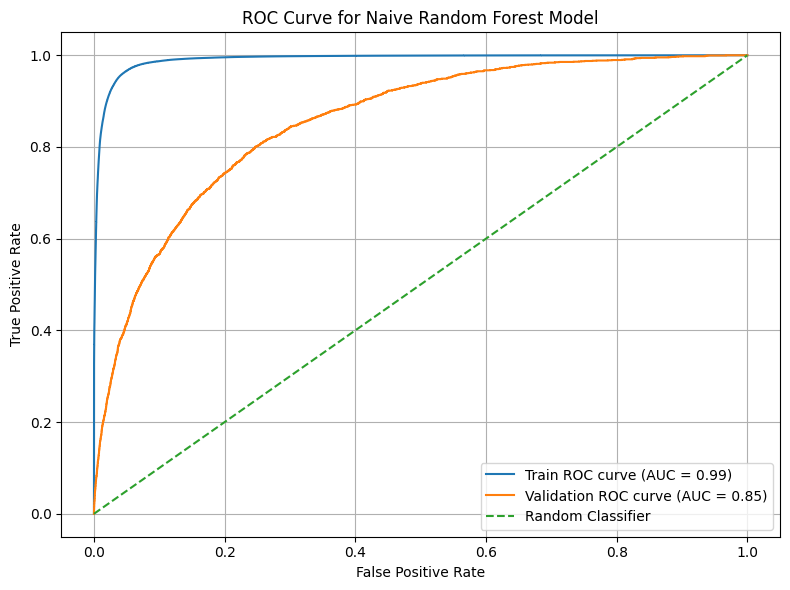

In [19]:
# Step 8: Plot ROC curve for the model's performance on Train vs. Test (Validation)
# Get the probabilities for the positive class (fraud)
y_train_proba = rf.predict_proba(X_train)[:, 1]
y_val_proba = rf.predict_proba(X_val)[:, 1]

# Compute ROC curve
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_proba)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f'Train ROC curve (AUC = {roc_auc_score(y_train, y_train_proba):.2f})')
plt.plot(fpr_val, tpr_val, label=f'Validation ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Naive Random Forest Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import numpy as np
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report 
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

In [6]:
# Initialize list to store selected features
selected_features_list = []

# Feature selection (Random Forest feature importance) - Separate this step first
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
X_train = pd.concat([fold_1_train, fold_2_train, fold_3_train, fold_4_train]).drop(columns='fraud_bool')
y_train = pd.concat([fold_1_train, fold_2_train, fold_3_train, fold_4_train])['fraud_bool']

In [7]:
# Fit a Random Forest model to get feature importances
rf_temp.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [8]:
# Get feature importances from rf_temp (the temporary model)
feature_importances = rf_temp.feature_importances_

# Create a DataFrame of feature names and their corresponding importance scores
feature_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Sort by importance
feature_df = feature_df.sort_values(by='Importance', ascending=False)

In [9]:
# Step 2: Calculate Cumulative Feature Importance
cumulative_importance = np.cumsum(feature_importances[feature_df.index])  # Cumulative sum of feature importances
total_importance = cumulative_importance[-1]  # Total importance (sum of all feature importances)

# Set a threshold for cumulative importance (e.g., 95%)
threshold = 0.95
best_num_features = np.where(cumulative_importance >= threshold * total_importance)[0][0] + 1  # Get index where cumulative importance exceeds threshold

# Select top N features based on cumulative importance
selected_features = feature_df['Feature'].head(best_num_features).values

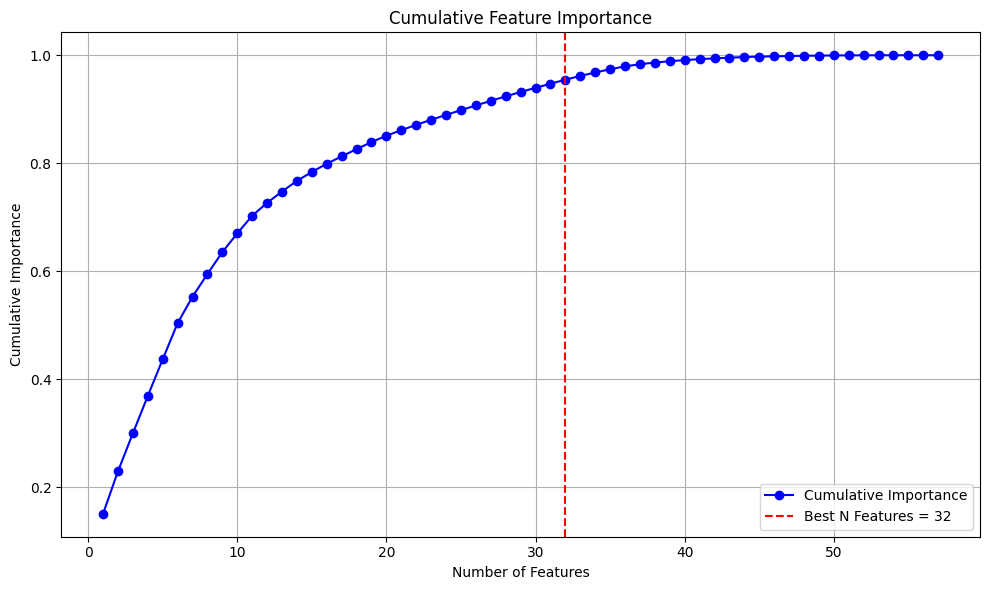

In [10]:
# Plot cumulative feature importance
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(cumulative_importance) + 1), cumulative_importance, marker='o', color='blue', label='Cumulative Importance')
plt.axvline(x=best_num_features, color='red', linestyle='--', label=f'Best N Features = {best_num_features}')  # Add a vertical line for the best N features
plt.xlabel('Number of Features')
plt.ylabel('Cumulative Importance')
plt.title('Cumulative Feature Importance')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
# Hyperparameter Tuning with Class Weights (using Optuna)
# Objective function for Optuna
def objective(trial):
    auc_roc = 0
    auc_pr = 0
    f1_score_avg = 0
    fold_classification_report = ""

    # Hyperparameters to tune
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'max_depth': trial.suggest_int('max_depth', 10, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', None])  # Adding class weight adjustment
    }

    # Loop through the 4 folds for training and tuning
    for i in range(4):  # Only use folds 1-4 for training and tuning
        # Load training data for the current fold
        fold_train_data = pd.read_csv(f"/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_{i+1}_train.csv")
        
        # Separate features and target variable (using selected features)
        X_train_fold = fold_train_data[selected_features]  # Using only selected features
        y_train_fold = fold_train_data['fraud_bool']

        # Sample 10% of the current fold for hyperparameter tuning
        X_train_sampled = X_train_fold.sample(frac=0.1, random_state=42)  # Take 10% of the fold data
        y_train_sampled = y_train_fold[X_train_sampled.index]  # Corresponding labels for the sampled data

        # Create the Random Forest model with the suggested hyperparameters
        rf = RandomForestClassifier(**param, random_state=42, n_jobs=-1)

        # Fit the model with the sampled data (SMOTE was not applied here)
        rf.fit(X_train_sampled, y_train_sampled)

        # Predict and calculate the probabilities on the current fold
        y_pred_fold = rf.predict(X_train_fold)
        y_proba_fold = rf.predict_proba(X_train_fold)[:, 1]  # Get probability for the positive class (fraud)

        # Calculate the evaluation metrics
        auc_roc += roc_auc_score(y_train_fold, y_proba_fold)
        auc_pr += average_precision_score(y_train_fold, y_proba_fold)
        f1_score_avg += f1_score(y_train_fold, y_pred_fold)

        # Get classification report for the fold
        fold_classification_report += f"\nFold {i+1} Classification Report:\n"
        fold_classification_report += classification_report(y_train_fold, y_pred_fold)

    # Calculate the average AUC-ROC, AUC-PR, and F1-score across all folds
    auc_roc /= 4  # Average over folds 1-4
    auc_pr /= 4
    f1_score_avg /= 4

    # Return the AUC-ROC as the objective to maximize
    return auc_roc  # We are maximizing AUC-ROC

In [12]:
# Run Optuna for hyperparameter tuning
study = optuna.create_study(direction='maximize') 
study.optimize(objective, n_trials=10) 

# Print the best hyperparameters and AUC-ROC score
print(f"Best hyperparameters: {study.best_params}")
print(f"Best AUC-ROC: {study.best_value:.4f}")

[I 2025-04-11 02:33:33,115] A new study created in memory with name: no-name-dd4ec8cd-ee14-4496-98c2-6f7bb8d4a4fe
[I 2025-04-11 02:34:37,808] Trial 0 finished with value: 0.9928353545684429 and parameters: {'n_estimators': 149, 'max_depth': 11, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9928353545684429.
[I 2025-04-11 02:35:36,817] Trial 1 finished with value: 0.9961552614377556 and parameters: {'n_estimators': 109, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 1 with value: 0.9961552614377556.
[I 2025-04-11 02:36:23,646] Trial 2 finished with value: 0.9910571883940271 and parameters: {'n_estimators': 96, 'max_depth': 10, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'log2', 'class_weight': None}. Best is trial 1 with value: 0.9961552614377556.
[I 2025-04-11 02:37:16,260] Trial 3 finished with value: 0.993

Best hyperparameters: {'n_estimators': 109, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'class_weight': None}
Best AUC-ROC: 0.9962


In [13]:
# Fit the final model
best_params = study.best_params
final_rf = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)

In [17]:
# Load fold 5 data for final evaluation on fold 5 (unseen data)
fold_5_val = pd.read_csv(f"/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_5_val.csv")
X_val = fold_5_val[selected_features] # Use selected features, no fraud bool col
y_val = fold_5_val['fraud_bool']

In [19]:
X_train_selected = X_train[selected_features]

# Fit the final model on the full training data (folds 1-4)
final_rf.fit(X_train_selected, y_train)

RandomForestClassifier(max_depth=15, min_samples_leaf=2, min_samples_split=8,
                       n_estimators=109, n_jobs=-1, random_state=42)

In [20]:
# Predict and evaluate on the test set (fold 5)
y_pred = final_rf.predict(X_val)
y_proba = final_rf.predict_proba(X_val)[:, 1]

# Print classification report
print("Final Model Evaluation on Test Set (Fold 5):")
print(classification_report(y_val, y_pred))

# Calculate ROC AUC
roc_auc = roc_auc_score(y_val, y_proba)
print(f'ROC AUC (on test set): {roc_auc:.2f}')

# Calculate F1 Score
f1 = f1_score(y_val, y_pred)
print(f'F1 Score (on test set): {f1:.4f}')

Final Model Evaluation on Test Set (Fold 5):
              precision    recall  f1-score   support

           0       0.99      0.97      0.98    178711
           1       0.12      0.35      0.18      1920

    accuracy                           0.97    180631
   macro avg       0.56      0.66      0.58    180631
weighted avg       0.98      0.97      0.97    180631

ROC AUC (on test set): 0.94
F1 Score (on test set): 0.1825


In [21]:
def evaluate_model(y_true, y_pred, y_proba=None, plot_pr_curve=True):
    print("Classification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # Key Metrics
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\nPrecision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    metrics = {
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': cm.tolist()
    }

    # Probabilistic metrics
    if y_proba is not None:
        pr_auc = average_precision_score(y_true, y_proba)
        metrics['auc_pr'] = pr_auc
        print(f"AUC-PR (Average Precision): {pr_auc:.4f}")

        roc_auc = roc_auc_score(y_true, y_proba)
        metrics['roc_auc'] = roc_auc
        print(f"ROC AUC:                   {roc_auc:.4f}")

        if plot_pr_curve:
            precision_pts, recall_pts, _ = precision_recall_curve(y_true, y_proba)
            plt.figure(figsize=(6, 5))
            plt.plot(recall_pts, precision_pts, marker='.', label='PR Curve')
            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title(f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()

    return metrics

Classification Report:
              precision    recall  f1-score   support

           0     0.9929    0.9734    0.9830    178711
           1     0.1235    0.3495    0.1825      1920

    accuracy                         0.9667    180631
   macro avg     0.5582    0.6614    0.5828    180631
weighted avg     0.9836    0.9667    0.9745    180631


Confusion Matrix:
[[173950   4761]
 [  1249    671]]

Precision: 0.1235
Recall:    0.3495
F1 Score:  0.1825
AUC-PR (Average Precision): 0.1259
ROC AUC:                   0.9371


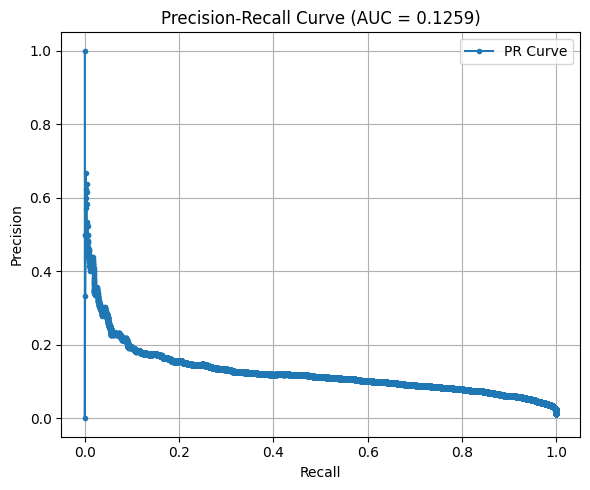

{'precision': 0.12352724594992637,
 'recall': 0.3494791666666667,
 'f1_score': 0.18253536452665942,
 'confusion_matrix': [[173950, 4761], [1249, 671]],
 'auc_pr': np.float64(0.1259091663135338),
 'roc_auc': np.float64(0.937106950957132)}

In [22]:
evaluate_model(y_val, y_pred, y_proba)